/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    0.8046   0.000000  0.000000  0.000000
1        Decision Tree    0.6573   0.184582  0.220573  0.200979


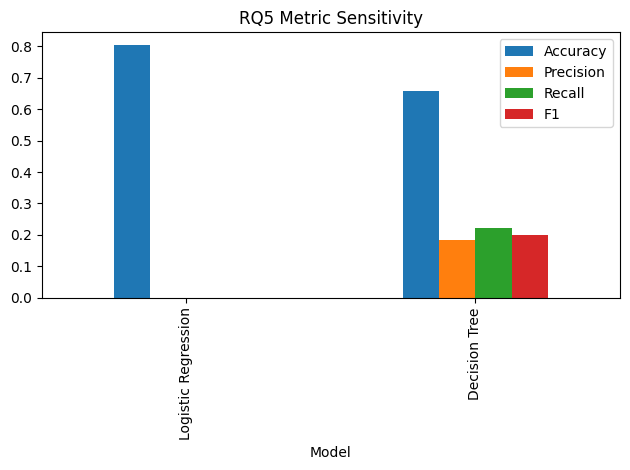

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load data
df = pd.read_csv(
    "/kaggle/input/datasets/sampath1092003/netflix-user-behavior-analysis-dataset/netflix_user_behavior_dataset.csv"
)

# Drop ID
df.drop("user_id", axis=1, inplace=True)

# Encode
for col in df.select_dtypes(include="object").columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("churned", axis=1)
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier()
}

results = []

for name, model in models.items():
    
    model.fit(X_train,y_train)
    
    pred = model.predict(X_test)
    
    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

results_df.to_csv(
    "/kaggle/working/RQ5_table.csv",
    index=False
)

results_df.plot(
    x="Model",
    kind="bar"
)

plt.title("RQ5 Metric Sensitivity")

plt.tight_layout()

plt.savefig("/kaggle/working/RQ5_figure.pdf")

plt.show()
